![WHCA UFFFS](../../logos.png)

# Tutorial: Create a STEPS Nowcast using HSAF H40B (MTG FCI)

In this notebook, we will create a nowcast. The processing steps build upon the work from the first notebook, where HSAF-H40B data was downloaded and preprocessed. 
The 'processed' folder containing the pre-processed files will be used as input for the nowcast.

To create a nowcast, we will use the pysteps library and the nowcast script, available in the EnhancedStepsNowcast.py

In this tutorial we are going to:
1. Load preprocessed HSAF H40B files
2. Select a region of interest
3. Run the nowcast 
4. Visualize and export the nowcast results

**Note:** H40B uses MTG FCI data with **10-minute** time steps (compared to 15 minutes for H60B). This affects the nowcast frequency, lead time interpretation, and cumulative rainfall calculations.

In [1]:
# Here, we load the required libraries.
import glob
import xarray as xr
import numpy as np
from pathlib import Path
import geopandas as gpd
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
from datetime import datetime, timedelta, date
import pandas as pd
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from pathlib import Path
import math
import matplotlib.colors as mcolors

# Load the nowcast function and the PySTEPS package
from enhanced_steps import EnhancedStepsNowcast
print("All libraries have been successfully imported!")

Pysteps configuration file found at: C:\Users\Aerts\pysteps\pystepsrc

All libraries have been successfully imported!


# Step 1: Define the data folder structure

In [2]:
# Create folders for our data
data_folder = Path("./h40b_data")
processed_folder = data_folder / "processed"        # This is the folder where, in the preprocessing script, the processed precipitation files were saved.
nowcasting_folder = data_folder / "nowcast"

# Create the folder for forecasts
Path(nowcasting_folder).mkdir(parents=True, exist_ok=True)

# Step 2: Define the nowcast parameters

In [3]:
settings = {
    "data_source": "h40b",     # Data source
    "ensemble": 1,             # Number of ensemble members
    "n_input_files": 10,       # Number of input files used
    "n_lead_times": 12,        # Number of lead times to forecast, each time step is 10 minutes
    "frequency": 10,           # Minutes between each time step (H40B = 10 min)
    "transform": "dB",         # Transformation used by pysteps ("dB", "log", ...)
    "threshold": 0.05,         # Threshold (mm/h) to define rain / no rain
    "buffer_distance": 5000,   # Distance in meters around a region of interest for cropping of the rainfall data
    "crs_out": "EPSG:4326",    # Output coordinate reference system
    "norain_thr": 0.005,       # Parameters for the Norain method
    "zerovalue": -15.0,        # Parameters for the Norain method
    "max_workers": 2,          # Number of processors to use
}

# Step 3: Search for downloaded and preprocessed HSAF files

In [4]:
# --- List of all available files ---
all_files = sorted(processed_folder.glob("*H40B*.nc"))
print("Available HSAF files in the processed folder:")
for i, f in enumerate(all_files):
    print(f"{i}: {f.name}")

Available HSAF files in the processed folder:
0: HSAF-H40B_20260114T000000.nc
1: HSAF-H40B_20260114T001000.nc
2: HSAF-H40B_20260114T002000.nc
3: HSAF-H40B_20260114T003000.nc
4: HSAF-H40B_20260114T004000.nc
5: HSAF-H40B_20260114T005000.nc
6: HSAF-H40B_20260114T010000.nc
7: HSAF-H40B_20260114T011000.nc
8: HSAF-H40B_20260114T012000.nc
9: HSAF-H40B_20260114T013000.nc


In [8]:
def find_latest_inputs(processed_folder, n=10, start_file=None):
    """
    Retrieve preprocessed HSAF files for the nowcast.
    """
    # List all H40B files and sort
    all_files = sorted(processed_folder.glob("*H40B*.nc"))
    
    if start_file is None:
        # Standard mode: take the last n files
        return list(reversed(all_files))[:n]
    else:
        # Start_file mode: find the index of the starting file
        start_file = Path(start_file).name  # only the name
        indices = [i for i, f in enumerate(all_files) if f.name == start_file]
        if not indices:
            raise ValueError(f"The start file '{start_file}' was not found in the folder.")
        start_idx = indices[0]
        # Return n files starting from start_idx
        return all_files[start_idx:start_idx + n]

# Mode 1: latest files
input_files = find_latest_inputs(processed_folder, n=10)

input_files

[WindowsPath('h40b_data/processed/HSAF-H40B_20260114T013000.nc'),
 WindowsPath('h40b_data/processed/HSAF-H40B_20260114T012000.nc'),
 WindowsPath('h40b_data/processed/HSAF-H40B_20260114T011000.nc'),
 WindowsPath('h40b_data/processed/HSAF-H40B_20260114T010000.nc'),
 WindowsPath('h40b_data/processed/HSAF-H40B_20260114T005000.nc'),
 WindowsPath('h40b_data/processed/HSAF-H40B_20260114T004000.nc'),
 WindowsPath('h40b_data/processed/HSAF-H40B_20260114T003000.nc'),
 WindowsPath('h40b_data/processed/HSAF-H40B_20260114T002000.nc'),
 WindowsPath('h40b_data/processed/HSAF-H40B_20260114T001000.nc'),
 WindowsPath('h40b_data/processed/HSAF-H40B_20260114T000000.nc')]

# Step 4: Load input files for the nowcast
The different data layers correspond to different time steps, we are going to combine these timesteps into a single 3D dataset: x (longitude), y (latitude), and time.
Afterwards, this single dataset can be used as input for our nowcast.


In [9]:
def open_as_time_stack(input_files):
    """
    This function opens the selected preprocessed HSAF files and combines them
    into a single xarray Dataset with the 'time' dimension.
    """
    if not input_files:
        raise FileNotFoundError("No input files found.")   # Check that files exist
    datasets = xr.open_mfdataset(input_files)              # Open and combine all files
    return datasets

# Load the selected files and create a Dataset with the time dimension
input_dataset = open_as_time_stack(input_files)

# Display the Dataset to verify its contents
display(input_dataset)

<xarray.Dataset> Size: 1GB
Dimensions:           (time: 10, y: 5431, x: 5702)
Coordinates:
  * x                 (x) float64 46kB -81.25 -81.22 -81.19 ... 81.22 81.25
  * y                 (y) float64 43kB 77.38 77.36 77.33 ... -77.36 -77.39
  * time              (time) datetime64[ns] 80B 2026-01-14 ... 2026-01-14T01:...
    spatial_ref       int64 8B 0
Data variables:
    precip_intensity  (time, y, x) float32 1GB dask.array<chunksize=(1, 2716, 2851), meta=np.ndarray>
Attributes: (12/16)
    Conventions:          CF-1.6
    title:                H-SAF H40B MTG FCI Precipitation
    source:               EUMETSAT H-SAF H40B
    satellite:            MTG-I1
    instrument:           FCI
    creator:              WMO Workshop
    ...                   ...
    geospatial_lat_max:   77.38379302114228
    geospatial_lon_min:   -81.24829056432118
    geospatial_lon_max:   81.25032259881716
    crs:                  EPSG:4326
    product_details:      https://hsaf.meteoam.it/Products/Detail?prod=H40B
    data_source:          hsaf-h40b

## What do you see in the displayed input dataset?
- **Dimensions (time, y, x)** - time: the number of time steps included, each spaced 10 minutes apart; y and x: the grid dimensions (latitude/longitude pixels)
- **Coordinates** - x (longitude), y (latitude), time (timestamps), spatial_ref (CRS info)
- **Data variables** - `precip_intensity`: the precipitation rate in mm/h at each grid cell and time step
- **Attributes** - metadata such as source (H-SAF H40B MTG FCI), CRS, spatial extent, etc.

# Step 5: Create an engine for the nowcast model

In [10]:
# Create the engine parameters from the settings defined in Step 2
steps_settings = {
    "datafolder": data_folder,                      # Folder containing the preprocessed HSAF files
    "ensemble": settings["ensemble"],               # Number of ensemble members
    "n_lead_times": settings["n_lead_times"],       # Number of forecast lead times
    "frequency": settings["frequency"],             # Frequency between each time step (minutes)
    "transform": settings["transform"],             # PySTEPS transformation ("dB", "log", etc.)
    "threshold": settings["threshold"],             # Threshold to distinguish rain / no rain
    "buffer_distance": settings["buffer_distance"], # Buffer around the area of interest
    "crs_out": settings["crs_out"],                 # Output coordinate reference system
    "norain_thr": settings["norain_thr"],           # Parameter for "no rain" method
    "zerovalue": settings["zerovalue"],             # Minimum value for "no rain"
    "max_workers": settings["max_workers"],         # Number of CPUs to use
}

# Create the nowcast engine object using the parameters above
engine = EnhancedStepsNowcast(steps_settings, "h40b")

# Step 6: Select the area of interest and inspect the input data for the nowcast

C:\Users\Aerts\AppData\Local\Temp\ipykernel_27688\2800429845.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


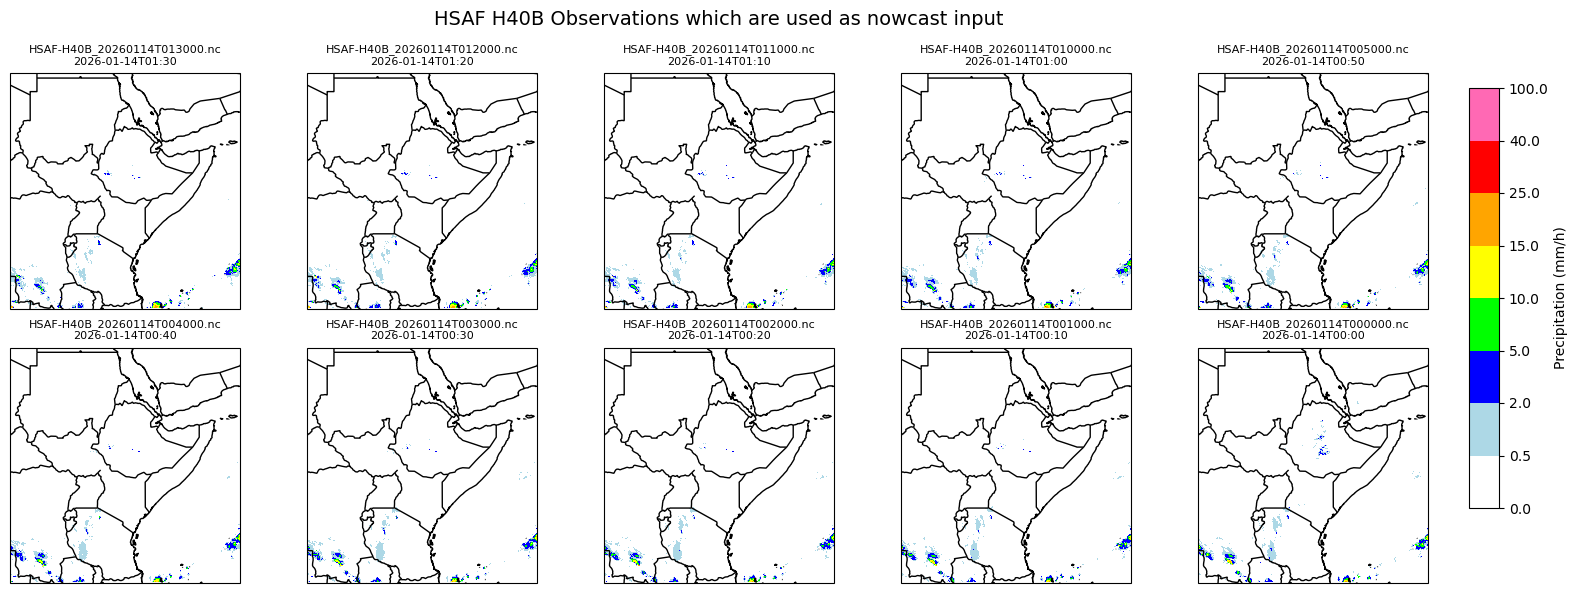

In [11]:
# Select here your area of interest 
region = {"lat_min": -12, "lat_max": 22, "lon_min": 21, "lon_max": 55}

# Define custom bounds and colors for precipitation 
bounds = [0, 0.5, 2, 5, 10, 15, 25, 40, 100]  # intensity bounds
colors = ["#ffffff", "#add8e6", "#0000ff", "#00ff00",
          "#ffff00", "#ffa500", "#ff0000", "#ff69b4"]  # associated colors
cmap = ListedColormap(colors)
norm = BoundaryNorm(boundaries=bounds, ncolors=cmap.N)

# Subplots configuration 
max_per_row = 5                             # maximum subplots per row
n_files = len(input_files)
n_rows = math.ceil(n_files / max_per_row)   # number of rows needed

# Create figure with small subplots
fig_width = max_per_row * 3
fig_height = n_rows * 3
fig, axes = plt.subplots(n_rows, max_per_row, figsize=(fig_width, fig_height),
                         subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()  

# Loop over each file to create a subplot
for i, f in enumerate(input_files):
    ds = xr.open_dataset(f)
    
    # Select region and first timestep
    data = ds.sel(
        x=slice(region["lon_min"], region["lon_max"]),
        y=slice(region["lat_max"], region["lat_min"])  # note reversed coordinates
    ).precip_intensity.isel(time=0)
    
    # Mask non-precipitation areas
    data_masked = data.where(data > 0)
    
    ax = axes[i]
    ax.set_extent([region["lon_min"], region["lon_max"], region["lat_min"], region["lat_max"]])
    ax.coastlines(resolution='10m', color='black')
    ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black')
    
    # Plot precipitation
    im = ax.pcolormesh(
        data_masked["x"], data_masked["y"], data_masked,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        norm=norm
    )
    
    # Add title for each subplot with filename and timestamp
    timestamp_str = str(data.time.values)[:16]
    ax.set_title(f"{f.name}\n{timestamp_str}", fontsize=8)

# Remove empty subplots
for j in range(i+1, n_rows*max_per_row):
    fig.delaxes(axes[j])

# Add a vertical colorbar to the right of all subplots
cbar_ax = fig.add_axes([1, 0.15, 0.02, 0.7])  
cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical', label="Precipitation (mm/h)")

fig.suptitle("HSAF H40B Observations which are used as nowcast input", fontsize=14)
plt.tight_layout()
plt.show()

# Step 7: Run the STEPS nowcast model with Pysteps
This command runs the STEPS nowcast model using the observation data and the area of interest you defined earlier.
Nowcast parameters (number of lead times, frequency, number of ensembles, thresholds, etc.) are taken from the settings defined in Step 2.

With the 10-minute frequency of H40B, each lead time step corresponds to 10 minutes into the future.

In [13]:
dataset_roi = input_dataset.sel(
    x=slice(region["lon_min"], region["lon_max"]),
    y=slice(region["lat_max"], region["lat_min"])  # note the reversed coordinates
)

nowcast_arrays, metadata = engine.nowcast_steps_pysteps(dataset_roi)

Rain fraction is: 0.04445626613860495, while minimum fraction is 0.005
unknown projection longlat
Inputs validated and initialized successfully.
Computing STEPS nowcast
-----------------------

Inputs
------
input dimensions: 1192x1193
km/pixel:         2.0
time step:        10 minutes

Methods
-------
extrapolation:          semilagrangian
bandpass filter:        gaussian
decomposition:          fft
noise generator:        nonparametric
noise adjustment:       no
velocity perturbator:   None
conditional statistics: no
precip. mask method:    incremental
probability matching:   cdf
FFT method:             numpy
domain:                 spatial

Parameters
----------
number of time steps:     12
ensemble size:            1
parallel threads:         2
number of cascade levels: 8
order of the AR(p) model: 2
precip. intensity threshold: -13.010299956639813
Nowcast components initialized successfully.
Rain fraction is: 0.016759536895874706, while minimum fraction is 0.0
Extrapolation complet

# Step 8: Export the results to a NetCDF file. 
A NetCDF (Network Common Data Form) file is a format used to store multidimensional data, such as precipitation on a spatial and temporal grid. 
It allows storing information about coordinates (latitude, longitude, time), variables (here precipitation intensity), and metadata.

In [14]:
output_path = nowcasting_folder
Path(output_path).mkdir(parents=True, exist_ok=True)
engine.settings["threddsdata"] = str(output_path)

engine.export_nowcast_to_netcdf(
    country="Country",
    nowcasting_arrays=nowcast_arrays,
    date_start=None,  
    metadata=metadata,
    reproject=True,
    data_source=settings["data_source"],
)

# Step 9: Inspect and visualize the nowcast results

In [15]:
# Open the NetCDF file containing the nowcast results
ds = xr.open_dataset(nowcasting_folder / "pysteps_h40b_latest.nc")

# Display some information about the NetCDF file
print("NetCDF file dimensions:", ds.dims)
print("Available variables:", list(ds.data_vars))
print("Coordinates:", list(ds.coords))
print("Attributes:", ds.attrs)

NetCDF file dimensions: FrozenMappingWarningOnValuesAccess({'x': 1193, 'y': 1192, 'time': 12})
Available variables: ['lon', 'lat', 'precip_intensity']
Coordinates: ['x', 'y', 'time']
Attributes: {'Conventions': 'CF-1.7', 'title': 'pysteps-generated nowcast', 'institution': 'the pySTEPS community (https://pysteps.github.io)', 'source': 'pysteps', 'history': '', 'references': '', 'comment': '', 'projection': '+proj=longlat +datum=WGS84 +no_defs'}


### Visualize a single timestep from the nowcast

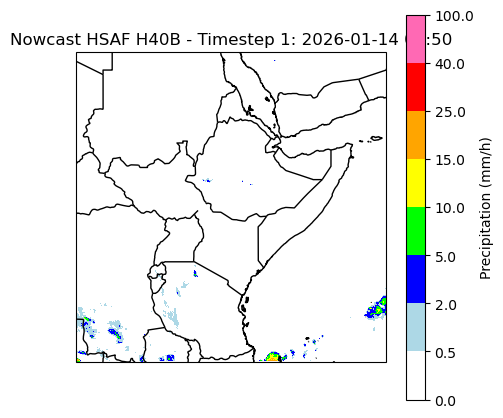

In [17]:
# Load the Nowcast HSAF dataset
ds = xr.open_dataset(nowcasting_folder / "pysteps_h40b_latest.nc")

# Each timestep corresponds to 10 minutes into the future
time_index = 1
data_plot = ds.precip_intensity.isel(time=time_index)

# Mask areas with no precipitation (0 mm/h)
data_plot_masked = data_plot.where(data_plot > 0)

# Define custom bounds and colors for the map
bounds = [0, 0.5, 2, 5, 10, 15, 25, 40, 100]  # Rain intensity bounds (mm/h)
colors = ["#ffffff", "#add8e6", "#0000ff", "#00ff00",
          "#ffff00", "#ffa500", "#ff0000", "#ff69b4"]  # Colors for each interval
cmap = ListedColormap(colors)
norm = BoundaryNorm(boundaries=bounds, ncolors=cmap.N)

# Flip only the precipitation data along the y-axis
data_flipped = data_plot_masked.values[::-1, :]

# Create the figure and set the projection
fig = plt.figure(figsize=(5, 5))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([ds.x.min(), ds.x.max(), ds.y.min(), ds.y.max()], crs=ccrs.PlateCarree())

# Add the base map
ax.coastlines(resolution='10m', color='black')
ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black')

# Plot the flipped precipitation data
im = ax.pcolormesh(
    ds.x, ds.y, data_flipped,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    norm=norm
)

# Add the colorbar
cbar = plt.colorbar(im, ax=ax, boundaries=bounds, ticks=bounds, label="Precipitation (mm/h)")

# Add the title with the timestep timestamp
time_str = pd.to_datetime(ds.time.isel(time=time_index).values).strftime("%Y-%m-%d %H:%M")
plt.title(f"Nowcast HSAF H40B - Timestep {time_index}: {time_str}")

plt.show()

### Create a video from the nowcast images

In [18]:
# Load the Nowcast dataset
ds = xr.open_dataset(nowcasting_folder / "pysteps_h40b_latest.nc")

# Choose the precipitation variable
varname = "precip_intensity" if "precip_intensity" in ds.data_vars else "precipitation"
var = ds[varname]

# Select the first ensemble member if present
if "ens_number" in var.dims:
    var = var.isel(ens_number=0)

# Function to format titles with date and time
def fmt_time(tarr, i):
    v = tarr.isel(time=i).values
    try:
        return np.datetime_as_string(np.asarray(v, dtype="datetime64[m]"), unit='m')
    except Exception:
        try:
            return v.strftime("%Y-%m-%d %H:%M")
        except Exception:
            return str(v)

# Define custom bounds and colors
bounds = [0, 0.5, 2, 5, 10, 15, 25, 40, 100]
colors = ["#ffffff", "#add8e6", "#0000ff", "#00ff00",
          "#ffff00", "#ffa500", "#ff0000", "#ff69b4", "#ff69b4"]
cmap = ListedColormap(colors)
norm = BoundaryNorm(boundaries=bounds, ncolors=cmap.N, extend='max')
cmap.set_bad("none")  # NaN values become transparent

# Extract coordinates
xname = next((c for c in ("x","lon","longitude") if c in var.coords), None)
yname = next((c for c in ("y","lat","latitude") if c in var.coords), None)
x = var[xname].values
y = var[yname].values

# Define extent for display
if y[0] > y[-1]:
    extent = [x.min(), x.max(), y.max(), y.min()]
    origin = "upper"
else:
    extent = [x.min(), x.max(), y.min(), y.max()]
    origin = "lower"

# Create figure and axes with Cartopy
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw={"projection": ccrs.PlateCarree()})
plt.close(fig)  
ax.set_extent([x.min(), x.max(), y.min(), y.max()])
ax.coastlines(resolution='10m', color='black')
ax.add_feature(cfeature.BORDERS, edgecolor='black')

# First frame with masked array
first_frame = var.isel(time=0).where(var.isel(time=0) > 0)
first_frame_flipped = np.ma.masked_invalid(first_frame.values[::-1, :]).astype(np.float32)

# Display the first frame
img = ax.imshow(
    first_frame_flipped,
    extent=extent,
    origin=origin,
    cmap=cmap,
    norm=norm
)

# Add colorbar
cbar = fig.colorbar(img, ax=ax, fraction=0.05, pad=0.02, ticks=bounds)
cbar.set_label("Precipitation (mm/h)")

# Title of the first frame
ax.set_title(fmt_time(var["time"], 0))

# Function to update the animation
def update(i):
    frame = var.isel(time=i).where(var.isel(time=i) > 0)
    frame_flipped = np.ma.masked_invalid(frame.values[::-1, :]).astype(np.float32)
    img.set_data(frame_flipped)
    ax.set_title(fmt_time(var["time"], i))
    return (img,)

# Create the animation
ani = FuncAnimation(fig, update, frames=var.sizes["time"], interval=600, blit=True)

# --- Path to save the GIF ---
# gif_path = Path("nowcast_animation.gif")  # Saves in the same folder as the notebook
# ani.save(gif_path, writer='pillow', fps=2)
# print(f"Nowcast animation saved as GIF at: {gif_path}")

# Display in Jupyter Notebook
HTML(ani.to_jshtml())

# Step 10: Extract nowcast precipitation rates for specific locations

In [19]:
nowcast_file = nowcasting_folder / "pysteps_h40b_latest.nc"
ds = xr.open_dataset(nowcast_file)

# Define points of interest
points = [
    {"name": "Kigali", "lat": -1.9441, "lon": 30.0619},
    {"name": "Juba", "lat": 4.8594, "lon": 31.5713},
    {"name": "Khartoum", "lat": 15.5007, "lon": 32.5599},
    {"name": "Kampala", "lat": 0.3476, "lon": 32.5825},
    {"name": "Addis Ababa", "lat": 8.9806, "lon": 38.7578},
]
# Select first ensemble member if present
varname = "precip_intensity" if "precip_intensity" in ds.data_vars else "precipitation"
var = ds[varname]
if "ens_number" in var.dims:
    var = var.isel(ens_number=0)  # First member

# Extract time series for each point (with Y-flip)
data_dict = {}
y_vals = var["y"].values
for pt in points:
    x_idx = abs(var["x"].values - pt["lon"]).argmin()       # find closest longitude index
    y_idx = abs(var["y"].values - pt["lat"]).argmin()       # find closest latitude index
    y_idx_flipped = len(y_vals) - 1 - y_idx                 # Flip Y index
    
    # Extract time series for this pixel
    rain_series = var[:, y_idx_flipped, x_idx]  
    data_dict[pt["name"]] = rain_series.values

# Create a DataFrame: rows = timestamps, columns = points
df_points = pd.DataFrame(data_dict, index=rain_series["time"].values)
df_points.index.name = "time"

# Save Nowcast DataFrame as Excel file in the same folder as notebook
# excel_path = Path(".") / "nowcast_points_timeseries.xlsx"
# df_points.to_excel(excel_path, index=True)
# print(f"DataFrame saved to {excel_path}")

print("Final DataFrame (Nowcast): each column = a point, each row = a timestep")
df_points

Final DataFrame (Nowcast): each column = a point, each row = a timestep


,Kigali,Juba,Khartoum,Kampala,Addis Ababa
time,,,,,
2026-01-14 01:40:00,0.000000,0.0,0.0,0.0,0.0
2026-01-14 01:50:00,0.000000,0.0,0.0,0.0,0.0
2026-01-14 02:00:00,0.000000,0.0,0.0,0.0,0.0
2026-01-14 02:10:00,0.000000,0.0,0.0,0.0,0.0
2026-01-14 02:20:00,0.000000,0.0,0.0,0.0,0.0
2026-01-14 02:30:00,0.000000,0.0,0.0,0.0,0.0
2026-01-14 02:40:00,0.000000,0.0,0.0,0.0,0.0
2026-01-14 02:50:00,0.000000,0.0,0.0,0.0,0.0
2026-01-14 03:00:00,0.000000,0.0,0.0,0.0,0.0


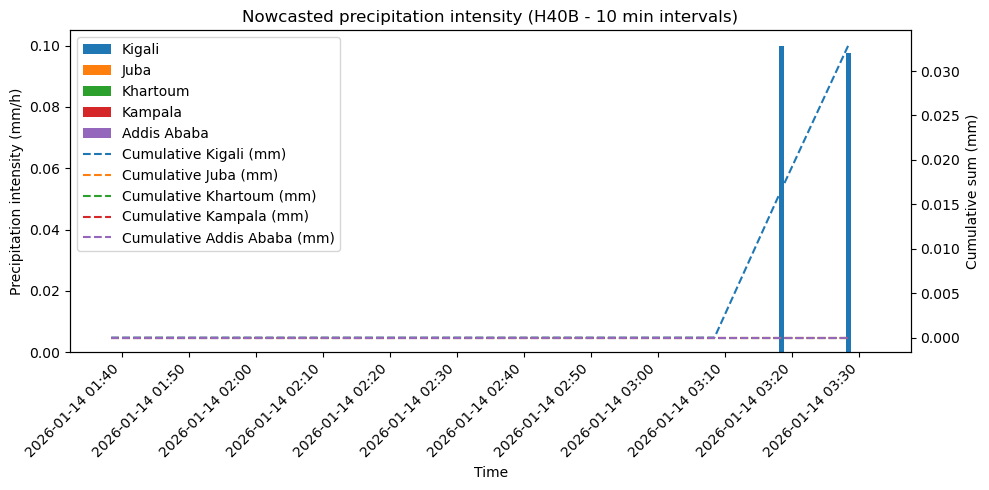

In [20]:
# Create the plot with bars (intensity) and lines (cumulative)
fig, ax1 = plt.subplots(figsize=(10, 5))

# Create a vector for the X axis
x = np.arange(len(df_points.index))
width = 0.4 / len(df_points.columns)  # bar width per point

# Plot bars for each point (intensity in mm/h)
for i, col in enumerate(df_points.columns):
    ax1.bar(
        x + i * width,             # shift bars
        df_points[col].values,     # intensity values (mm/h)
        width=width, 
        label=col
    )

# Format X axis with timestamps
ax1.set_xticks(x + width * (len(df_points.columns) - 1) / 2)
ax1.set_xticklabels(df_points.index.strftime("%Y-%m-%d %H:%M"), rotation=45, ha="right")

ax1.set_ylabel("Precipitation intensity (mm/h)")
ax1.set_xlabel("Time")

# Convert to mm per 10-minute step (H40B interval)
df_points_mm = df_points * (10 / 60)   # mm/h * (10/60) = mm per 10 min

# Add a second Y axis for cumulative totals
ax2 = ax1.twinx()
for col in df_points.columns:
    ax2.plot(
        x, 
        df_points_mm[col].cumsum(), linestyle="--",
        label=f"Cumulative {col} (mm)"
    )

ax2.set_ylabel("Cumulative sum (mm)")

# Merge legends (bars + lines)
lines_labels = [ax.get_legend_handles_labels() for ax in [ax1, ax2]]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
ax1.legend(lines, labels, loc="upper left")

plt.title("Nowcasted precipitation intensity (H40B - 10 min intervals)")
plt.tight_layout()
plt.show()

# Step 11: Select alert thresholds
The nowcast can provide precipitation forecasts for upcoming periods. Based on this forecast, alerts can be issued in case of extreme rainfall.
The thresholds for issuing these alerts may vary by location. In this part of the script, we can experiment with thresholds and observe the effect on alert issuance at different locations.

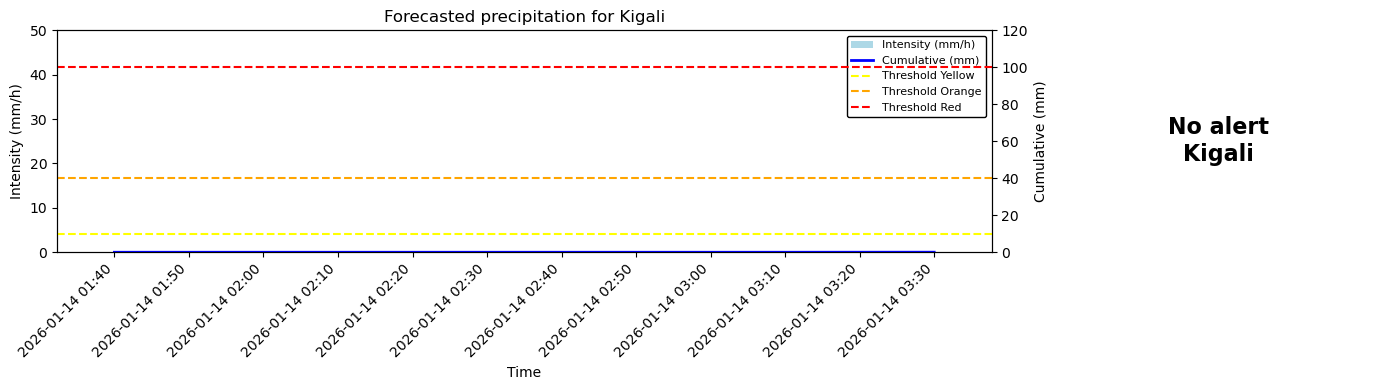

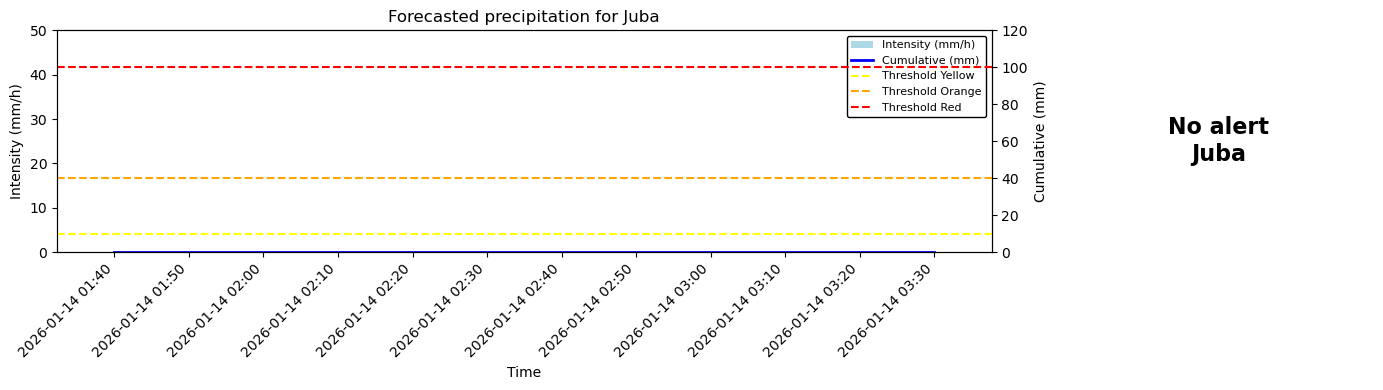

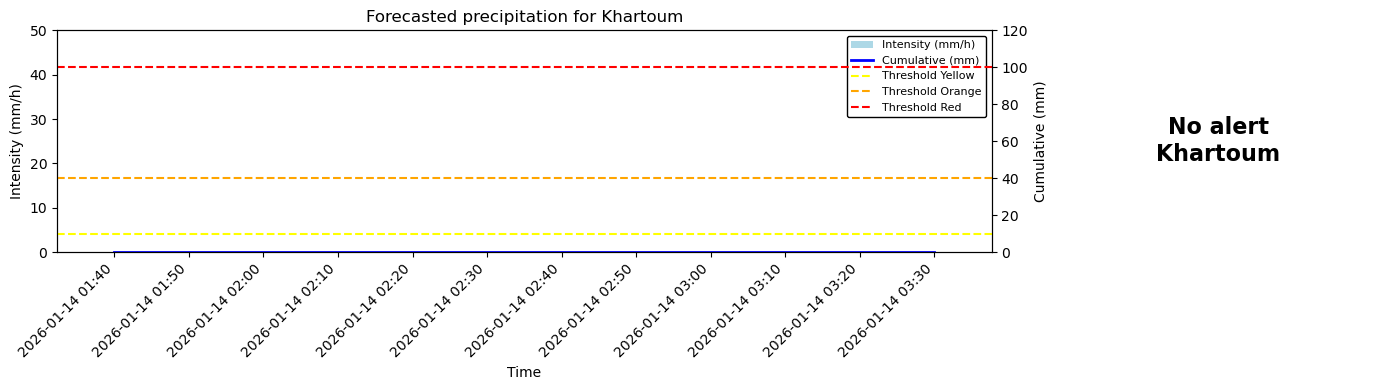

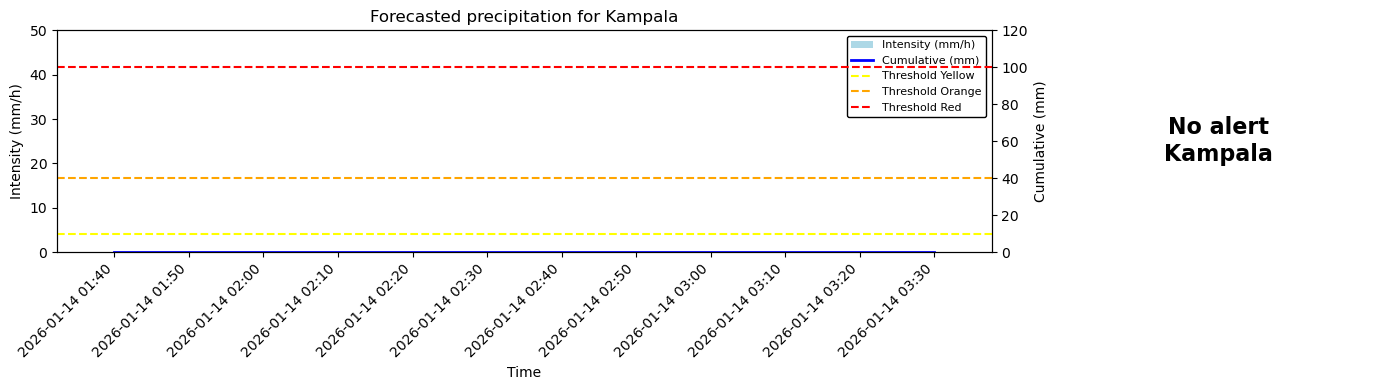

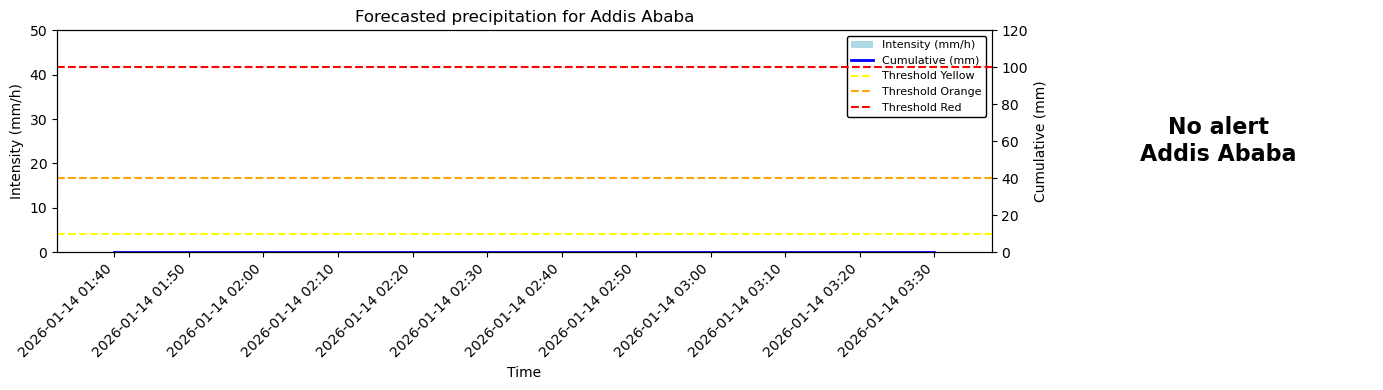

In [21]:
# Alert thresholds and associated colors
thresholds = {"yellow": 10, "orange": 40, "red": 100}
colors = {"yellow": "yellow", "orange": "orange", "red": "red"}

# Convert intensity -> cumulative per 10-min step (H40B)
df_mm = df_points * (10 / 60)   # mm/h * (10/60) = mm per 10 min
df_cum = df_mm.cumsum()

# Loop over each point
for point in df_points.columns:
    x = np.arange(len(df_points.index))

    # Determine alert level
    alert_level = None
    for level, thresh in sorted(thresholds.items(), key=lambda x: x[1]):
        if df_cum[point].max() >= thresh:
            alert_level = level

    # Create figure with 2 horizontal subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={"width_ratios": [3, 1]})

    # Histogram for intensity
    ax1.bar(x, df_points[point].values, color="lightblue", width=0.4, label="Intensity (mm/h)")

    # Cumulative line on secondary Y-axis
    ax_cum = ax1.twinx()
    ax_cum.plot(x, df_cum[point].values, color="blue", linewidth=2, label="Cumulative (mm)")

    # Threshold lines
    for level, thresh in thresholds.items():
        ax_cum.axhline(thresh, color=colors[level], linestyle="--", label=f"Threshold {level.capitalize()}")

    # Format X and Y axes
    ax1.set_xticks(x)
    ax1.set_xticklabels(df_points.index.strftime("%Y-%m-%d %H:%M"), rotation=45, ha="right")
    ax1.set_xlabel("Time")
    ax1.set_ylabel("Intensity (mm/h)")
    ax_cum.set_ylabel("Cumulative (mm)")
    ax1.set_ylim(0, max(df_points[point].max(), 50))
    ax_cum.set_ylim(0, max(df_cum[point].max(), 120))
    ax1.set_title(f"Forecasted precipitation for {point}")

    # Merge legends with white background above the lines
    lines_labels = [ax.get_legend_handles_labels() for ax in [ax1, ax_cum]]
    lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
    legend = ax1.legend(lines, labels, loc="upper right", fontsize=8, facecolor="white",
                        edgecolor="black", framealpha=1)

    # Alert subplot on the right
    ax2.axis('off')
    if alert_level:
        circle_color = colors[alert_level]
        ax2.add_patch(plt.Circle((0.5, 0.5), 0.3, color=circle_color))
        ax2.text(0.5, 0.5, f"ALERT {alert_level.upper()}\n{point}",
                 color="black", fontsize=16, ha="center", va="center", weight="bold")
    else:
        ax2.text(0.5, 0.5, f"No alert\n{point}",
                 color="black", fontsize=16, ha="center", va="center", weight="bold")

    plt.tight_layout()
    plt.show()

# Congratulations, you have successfully completed the nowcast component of the workshop! 🎉